In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from helper_functions.helper_functions import *
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernelSmarterRefine,BnetMean
from torch.utils.data import DataLoader
from tqdm import tqdm

In [42]:
device = 'cuda'
pin_memory = True
step = 480
THICKNESS_MM = 3.5  # sample thickness

model_path = '/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs_official/smart_net_heating_and_cooling/best_model_clean.pth'

# Mode of the experimentation
data = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/topology_exp/topology_exp_bscans'
depth = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/topology_exp/topology_exp_masks'

sigma_list = [0.065] 
noise_augmentation=ComposeBScanTransforms([NoiseAdditionExperiment(sigma=sigma_list[-1])])

model=BnetSmallKernelSmarterRefine().to(device)
# model=BnetMean().to(device)
state_dict=torch.load(model_path)
model.load_state_dict(state_dict)
model.eval()

# validation (robustness metric only)
test_dataset = BScanDepthDataset(
    bscan_dir=data,
    depth_dir=depth,
    transform=noise_augmentation,
    normalization_path="/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/normalization_params.npz",
    derivative_mode=None,
    log_scaling=True,
    cooling_phase=False
)

# -------------------------
# Loaders
# -------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=pin_memory
)

In [44]:
model.eval()

pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(test_loader):

        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)


        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 30/30 [00:04<00:00,  6.04it/s]


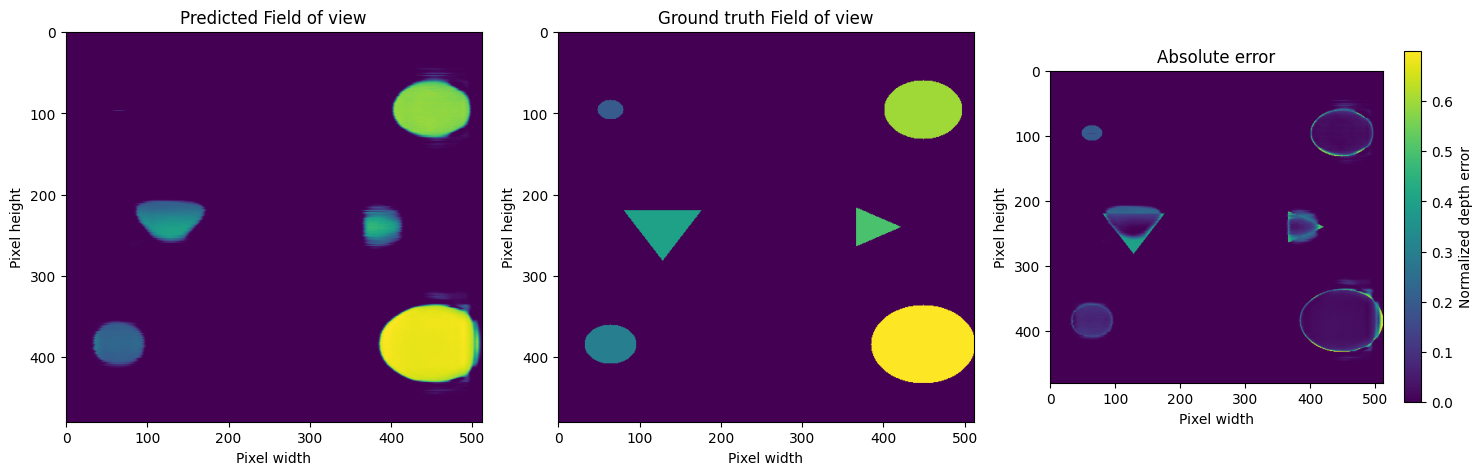

In [48]:
visualize_global_prediction(pred_all,mask_all,n=1)

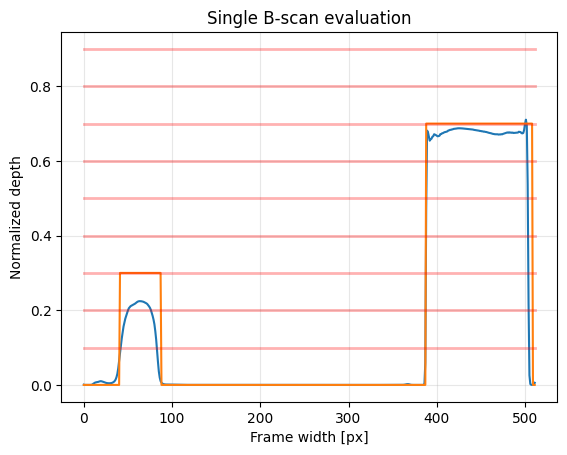

In [38]:
visualize_bscan_prediction(pred_all,mask_all,n=1,level=400)

In [45]:
results=compute_dataset_depth_metrics(pred_all,mask_all,[0.2,0.3,0.4,0.5,0.6,0.7],thickness_mm=THICKNESS_MM)
print_dataset_depth_metrics(results,THICKNESS_MM)

=== DATASET GLOBAL ROI METRICS ===
MAE:   0.085949
MedAE: 0.033756
RMSE:  0.143162
Count: 22313

=== DATASET GLOBAL ROI METRICS [mm] ===
MAE:   0.300821 mm
MedAE: 0.118145 mm
RMSE:  0.501066 mm

=== PER-DEPTH-LEVEL ROI METRICS ===
Depth=0.200 | MAE=0.197658 | MedAE=0.199404 | RMSE=0.197974 | Count=592
Depth=0.300 | MAE=0.084511 | MedAE=0.080584 | RMSE=0.088331 | Count=2394
Depth=0.400 | MAE=0.147947 | MedAE=0.099745 | RMSE=0.200485 | Count=2965
Depth=0.500 | MAE=0.174649 | MedAE=0.129749 | RMSE=0.212312 | Count=1332
Depth=0.600 | MAE=0.063567 | MedAE=0.025826 | RMSE=0.125874 | Count=5407
Depth=0.700 | MAE=0.060630 | MedAE=0.027345 | RMSE=0.125076 | Count=9623

=== PER-DEPTH-LEVEL ROI METRICS [mm] ===
Depth=0.200 | MAE=0.691802 mm | MedAE=0.697914 mm | RMSE=0.692909 mm | Count=592
Depth=0.300 | MAE=0.295790 mm | MedAE=0.282045 mm | RMSE=0.309159 mm | Count=2394
Depth=0.400 | MAE=0.517813 mm | MedAE=0.349107 mm | RMSE=0.701697 mm | Count=2965
Depth=0.500 | MAE=0.611270 mm | MedAE=0.45412

In [46]:
results_iou=compute_iou_over_concatenated_sims(pred_all,mask_all,sim_size=480)
print_iou_results(results_iou)

=== GLOBAL IoU ===
IoU:          0.807377
Intersection: 21058
Union:        26082
Num sims:     1

=== PER-SIMULATION IoU ===
Sim 00 | IoU=0.807377 | Intersection=21058 | Union=26082


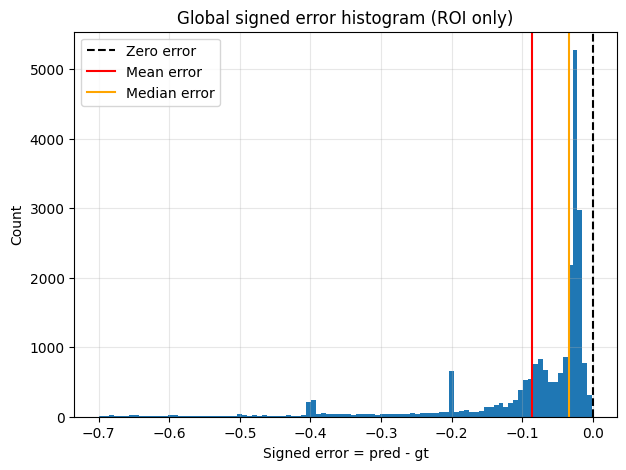

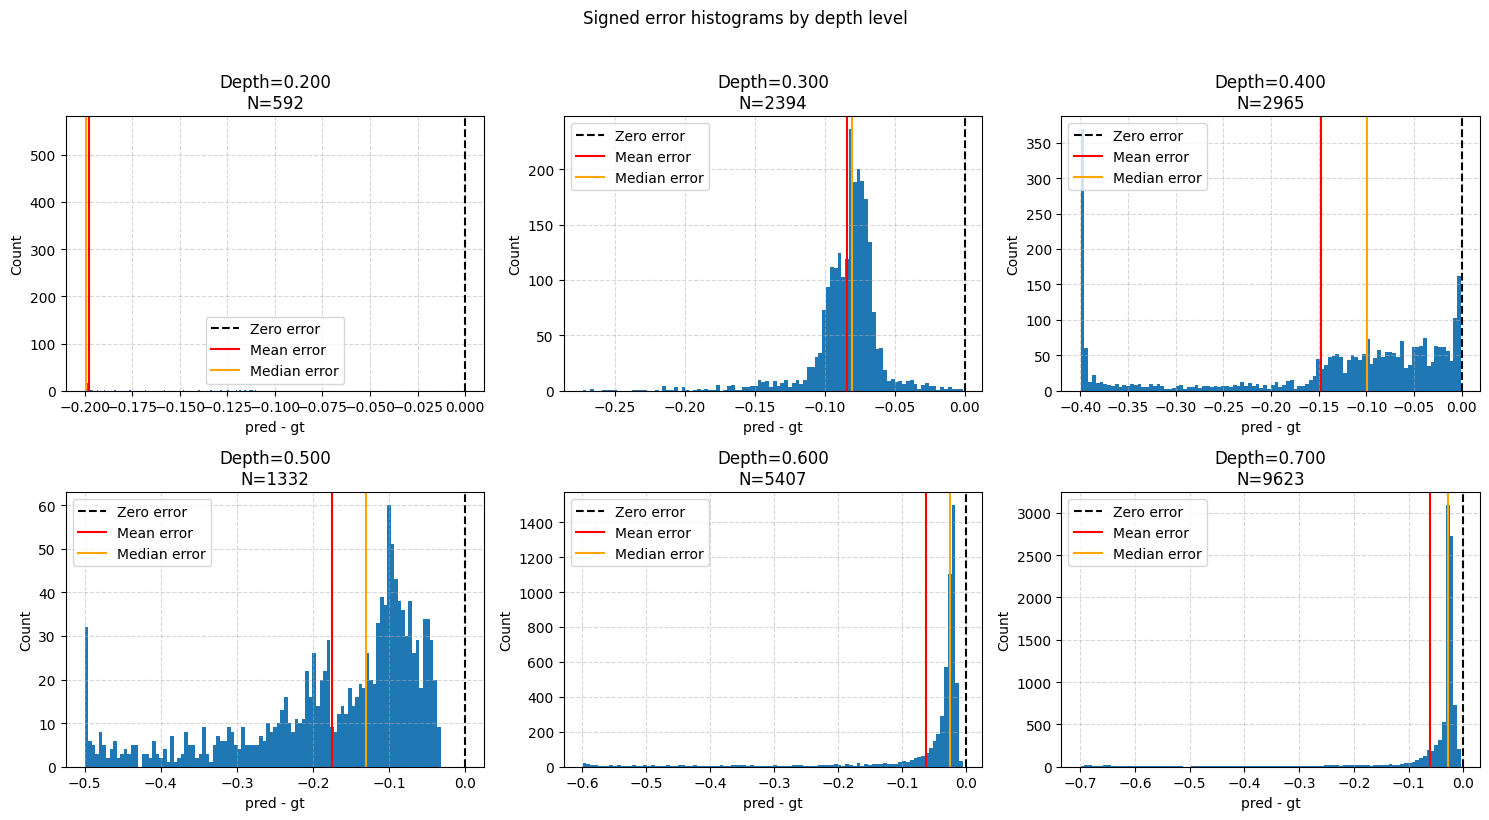

=== GLOBAL ERROR STATS ===
Mean signed error:   -0.085949
Median signed error: -0.033756
Mean absolute error: 0.085949

=== PER-LEVEL ERROR STATS ===
Depth=0.200 | Mean signed=-0.197658 | Median signed=-0.199405 | Mean abs=0.197658 | Count=592
Depth=0.300 | Mean signed=-0.084511 | Median signed=-0.080598 | Mean abs=0.084511 | Count=2394
Depth=0.400 | Mean signed=-0.147947 | Median signed=-0.099745 | Mean abs=0.147947 | Count=2965
Depth=0.500 | Mean signed=-0.174649 | Median signed=-0.129903 | Mean abs=0.174649 | Count=1332
Depth=0.600 | Mean signed=-0.063567 | Median signed=-0.025826 | Mean abs=0.063567 | Count=5407
Depth=0.700 | Mean signed=-0.060630 | Median signed=-0.027345 | Mean abs=0.060630 | Count=9623


In [47]:
plot_error_histograms_with_levels(pred_all,mask_all,depth_levels=[0.2,0.3,0.4,0.5,0.6,0.7],max_cols=3)